# Customer Churn Prediction

## Comparative Study of XGBoost and MLP Classifiers

This project develops and compares machine learning models for customer churn prediction. The workflow covers data preprocessing, exploratory data analysis, model development, hyperparameter optimization, and evaluation using classification metrics and ROC-AUC.

### Models
- XGBoost Classifier
- Keras / TensorFlow Multilayer Perceptron (MLP)
- Scikit-learn MLPClassifier

### Main evaluation metrics
Accuracy, Precision, Recall, F1-score, confusion matrices, and ROC-AUC.

Import libararies

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from scikeras.wrappers import KerasClassifier


from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam



1. Data gathering

Load the dataset

In [16]:
df = pd.read_csv("../data/churn.csv")
df.head()

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0


2. Data pre-processing & EDA

Column info

Check missing values

Age and Satisfaction_score both columns have 500 missing values each .

Missing percentage

In [17]:
missing = df[["Age", "Satisfaction_Score"]].isnull().sum()
missing_percentage = (missing / len(df)) * 100

print(missing_percentage)

Age                   10.0
Satisfaction_Score    10.0
dtype: float64


10% missing value percentage is acceptable.

check the distribution of those two

In [18]:
df[["Age", "Satisfaction_Score"]].describe()

,Age,Satisfaction_Score
count,4500.000000,4500.00000
mean,43.582222,5.54600
std,14.969559,2.86929
min,18.000000,1.00000
25%,31.000000,3.00000
50%,43.000000,6.00000
75%,56.000000,8.00000
max,69.000000,10.00000


In [19]:
df["Satisfaction_Score"].describe()

count    4500.00000
mean        5.54600
std         2.86929
min         1.00000
25%         3.00000
50%         6.00000
75%         8.00000
max        10.00000
Name: Satisfaction_Score, dtype: float64

The mean and median values are relatively close, suggesting limited skewness. Mean imputation was therefore selected for the missing values.

In [20]:
cols_to_impute = ['Age', 'Satisfaction_Score']


for col in cols_to_impute:
    
    # calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    #calculate bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # check outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    
    # check skewness
    skew_value = df[col].skew()
    
    # select the method
    if outlier_count > 0 or abs(skew_value) > 0.5:
        fill_value = df[col].median()
        method_used = "Median"
    else:
        fill_value = df[col].mean()
        method_used = "Mean"
    
    # fill missing values
    df[col] = df[col].fillna(fill_value)
    
    # print details
    print(f"--- Analysis for '{col}' ---")
    print(f"  Skewness: {skew_value:.3f}")
    print(f"  Outliers Found: {outlier_count} ({outlier_count/len(df)*100:.2f}%)")
    print(f"  Decision: Used '{method_used}' (Value: {fill_value:.2f})")
    print("-" * 30)

# Final verification 
print("\nRemaining Missing Values:\n", df[cols_to_impute].isnull().sum())

--- Analysis for 'Age' ---
  Skewness: -0.007
  Outliers Found: 0 (0.00%)
  Decision: Used 'Mean' (Value: 43.58)
------------------------------
--- Analysis for 'Satisfaction_Score' ---
  Skewness: -0.026
  Outliers Found: 0 (0.00%)
  Decision: Used 'Mean' (Value: 5.55)
------------------------------

Remaining Missing Values:
 Age                   0
Satisfaction_Score    0
dtype: int64


check churn distribution

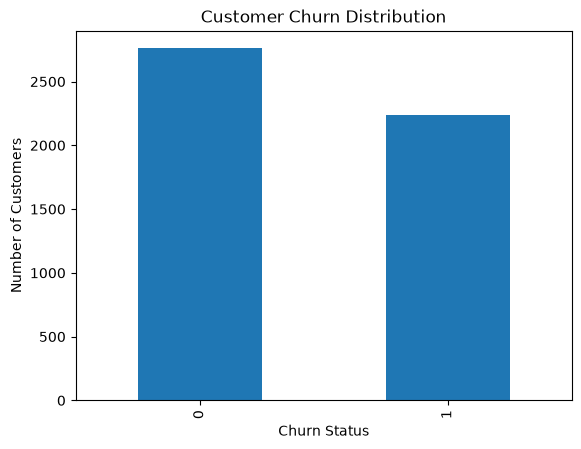

In [21]:
churn_counts = df["Churned"].value_counts()

churn_counts.plot(kind="bar")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

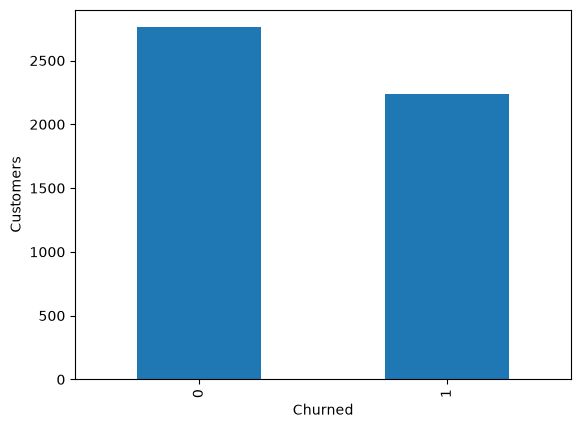

In [22]:
df["Churned"].value_counts().plot(kind="bar")

plt.xlabel("Churned")
plt.ylabel("Customers")
plt.show()

Since the dataset has both churned and retained customers, it suitable to binary classification.

coorelation matrix and heatmap 

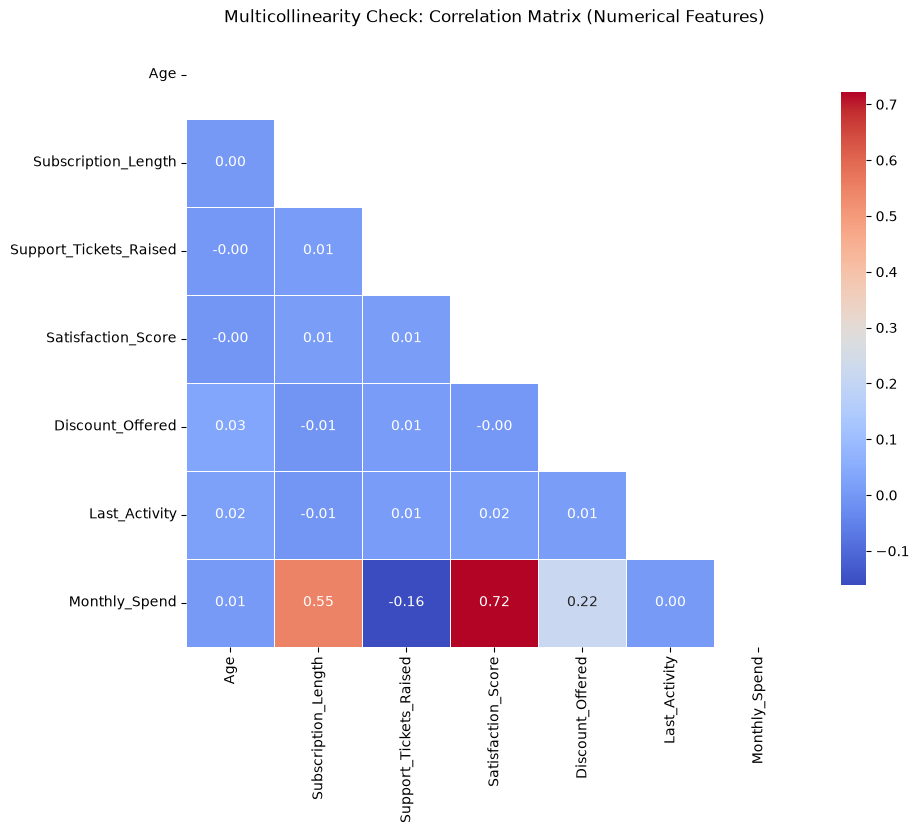

In [23]:
numerical_feats = ['Age', 'Subscription_Length', 'Support_Tickets_Raised', 
                   'Satisfaction_Score', 'Discount_Offered', 'Last_Activity', 'Monthly_Spend']

corr_matrix = df[numerical_feats].corr()

# 3. Plot a full heatmap (with a mask to hide the upper triangle for clarity)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Multicollinearity Check: Correlation Matrix (Numerical Features)")
plt.show()


The correlation matrix was inspected for potentially redundant predictors.

Correlation Heatmap

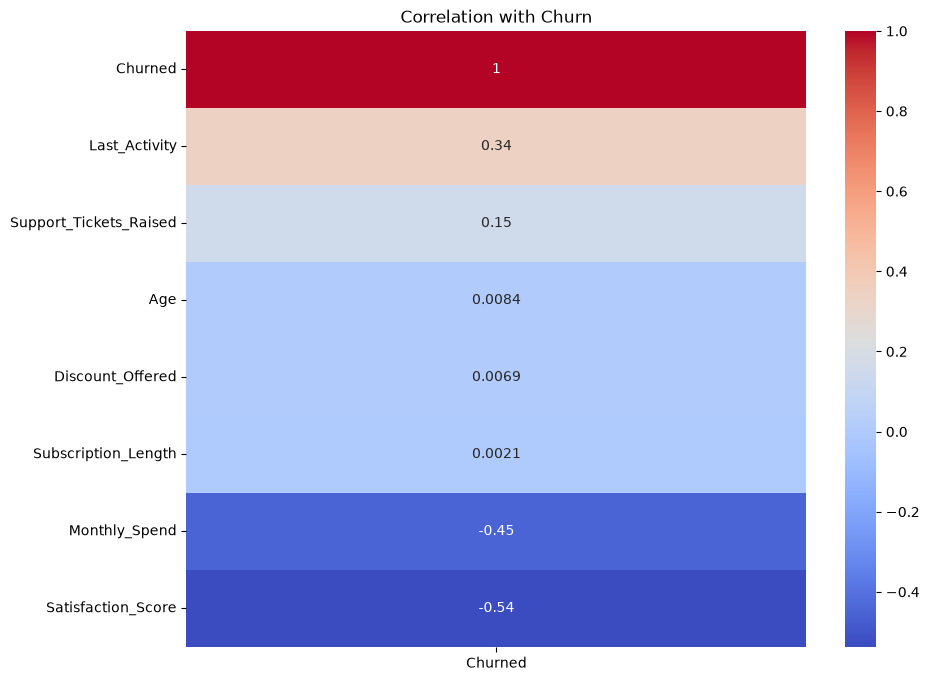

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True)[['Churned']].sort_values(by='Churned', ascending=False),
            annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Churn')
plt.show()

This means that when the monthly spending of customers increases, the likelihood of churn goes down. 
Similarly, the customers who has high satisfaction score, the likelihood of churn goes down. 

Box plots for numerical variables

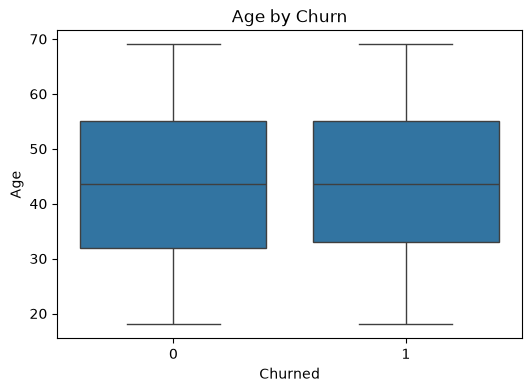

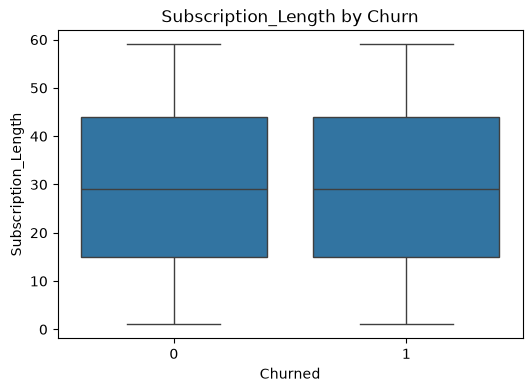

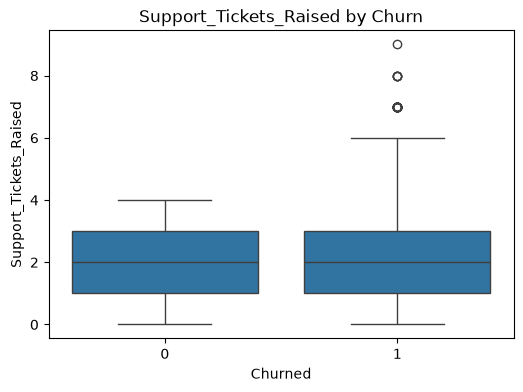

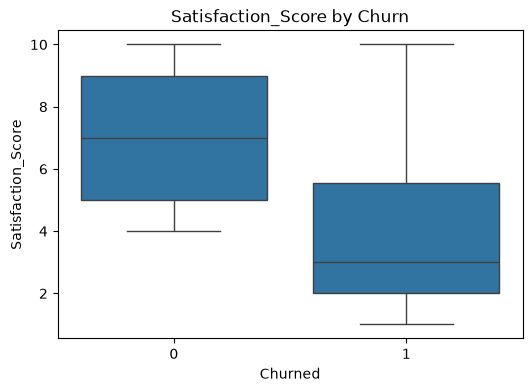

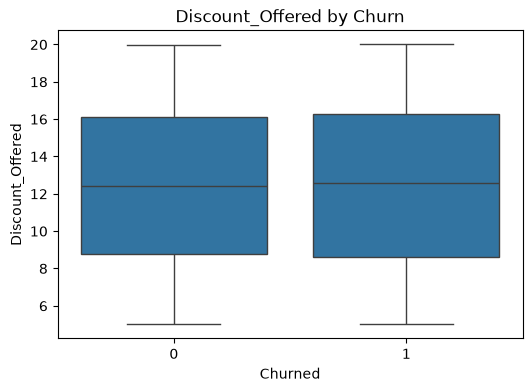

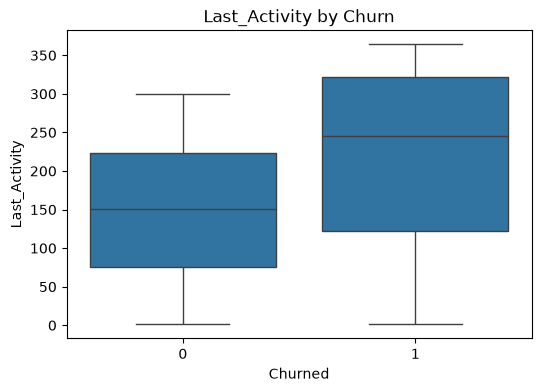

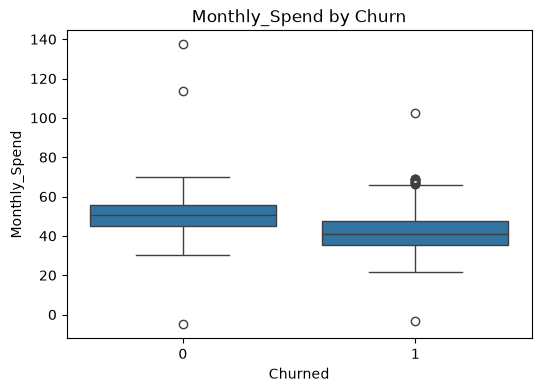

In [25]:
numerical_cols = ['Age','Subscription_Length','Support_Tickets_Raised','Satisfaction_Score',
                  'Discount_Offered','Last_Activity','Monthly_Spend']
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churned', y=col, data=df)
    plt.title(f'{col} by Churn')
    plt.show()

Bar charts for categorical variables

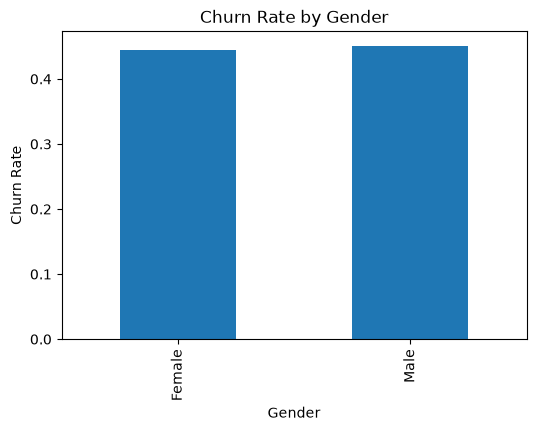

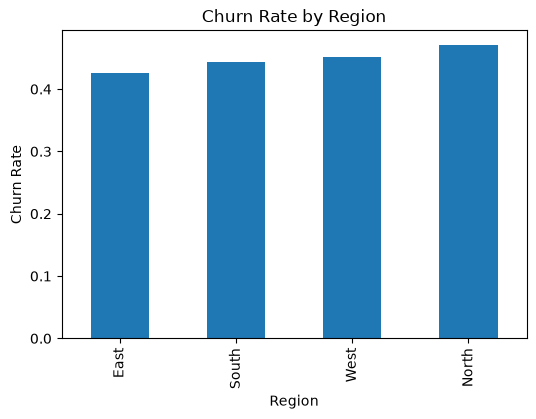

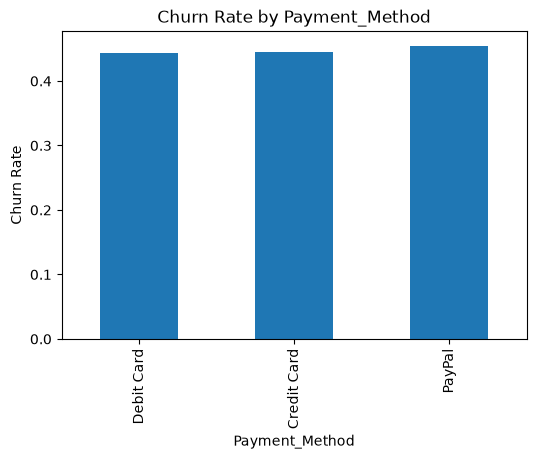

In [26]:
cat_cols = ['Gender','Region','Payment_Method']
for col in cat_cols:
    churn_rate = df.groupby(col)['Churned'].mean().sort_values()
    plt.figure(figsize=(6,4))
    churn_rate.plot(kind='bar')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.show()

3. Feature engineering / selection 



In [27]:
X = df.drop(
    ["Churned", "Customer_ID"],
    axis=1
)

y = df["Churned"]

Customer_ID was excluded because it is an identifier rather than a meaningful predictive feature.

Encode categorical variables

In [28]:
X = pd.get_dummies(X, drop_first=True)  

Train-test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Hyperparameter Optimization for XGBoost

In [30]:
params = {
    "n_estimators":[482,483,484],       
    "max_depth":[2,3,4],                
    "learning_rate":[0.095,0.1, 0.105], 
}


grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


grid_xgb.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.095, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [482, 483, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

Best model - XGB

In [31]:
best_xgb = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)


Best Parameters: {'learning_rate': 0.105, 'max_depth': 3, 'n_estimators': 482}


Hyperparameter Optimization for MLP - keras

In [32]:
def create_my_model(neurons=128, dropout_rate=0.25, learning_rate=0.001):
    
    model = Sequential()
   
    model.add(Dense(units=neurons, 
                    input_shape=(X_train.shape[1],),  
                    activation='relu'))
    
    model.add(Dense(units=neurons, activation='relu'))
    
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(units=1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', 
                  optimizer=optimizer, 
                  metrics=['accuracy'])
    
    return model

keras_estimator = KerasClassifier(
    model=create_my_model,
    epochs=100,           
    batch_size=32,       
    verbose=0            
)

param_grid = {
    'clf__model__neurons': [200,220,240],          
    'clf__model__dropout_rate': [0.3,0.4],   
    'clf__model__learning_rate': [0.005,0.007],    
    'clf__epochs': [15],                   
    'clf__batch_size': [56]               
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', keras_estimator)
])

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                      
    scoring='f1',              
    n_jobs=-1,
    verbose=1
)


In [33]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Shashen Perera\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\Shashen Perera\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__batch_size': [56], 'clf__epochs': [15], 'clf__model__dropout_rate': [0.3, 0.4], 'clf__model__learning_rate': [0.005, 0.007], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_gl

Best model - MLP - keras

In [34]:
best_model = grid.best_estimator_
print(f"\nBest Parameters:",grid.best_params_)
print(f"Best model:", best_model)


Best Parameters: {'clf__batch_size': 56, 'clf__epochs': 15, 'clf__model__dropout_rate': 0.4, 'clf__model__learning_rate': 0.007, 'clf__model__neurons': 200}
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 KerasClassifier(batch_size=56, epochs=15, model=<function create_my_model at 0x00000197D8D53CE0>, model__dropout_rate=0.4, model__learning_rate=0.007, model__neurons=200, verbose=0))])


Hyperparameter Optimization for MLP - Scikit-learn

In [35]:
mlp_params = {
    "mlp__hidden_layer_sizes": [(109), (110,), (111)],  
    "mlp__alpha": [0.085, 0.09,0.095],                  
    "mlp__learning_rate_init": [0.012, 0.013, 0.014],   
}
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPClassifier(random_state=42, max_iter=500))  
])

grid_mlp = GridSearchCV(
    mlp_pipeline,
    mlp_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
print("Starting MLP GridSearch...")
grid_mlp.fit(X_train, y_train)

Starting MLP GridSearch...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__alpha': [0.085, 0.09, ...], 'mlp__hidden_layer_sizes': [109, (110,), ...], 'mlp__learning_rate_init': [0.012, 0.013, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

best model - MLP - Scikit-learn

In [36]:
best_mlp = grid_mlp.best_estimator_
print("Best Parameters:", grid_mlp.best_params_)


Best Parameters: {'mlp__alpha': 0.085, 'mlp__hidden_layer_sizes': 111, 'mlp__learning_rate_init': 0.014}


Evaluate All 3(XGBoost, MLP-keras, MLP-Scikit-learn)

In [37]:
# --- XGBoost Evaluation ---
y_pred_xgb = best_xgb.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

# --- Keras MLP Evaluation ---
y_pred_k_mlp = best_model.predict(X_test)
# Convert probabilities to binary labels
y_pred_k_mlp = (y_pred_k_mlp > 0.5).astype(int)
mlp_k_accuracy = accuracy_score(y_test, y_pred_k_mlp)
mlp_k_precision = precision_score(y_test, y_pred_k_mlp)
mlp_k_recall = recall_score(y_test, y_pred_k_mlp)
mlp_k_f1 = f1_score(y_test, y_pred_k_mlp)

# --- Scikit-learn MLP Evaluation ---
y_pred_mlp = best_mlp.predict(X_test)
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

comparison table

In [38]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "Keras MLP", "Sklearn MLP"],
    "Accuracy": [xgb_accuracy, mlp_k_accuracy, mlp_accuracy],
    "Precision": [xgb_precision, mlp_k_precision, mlp_precision],
    "Recall": [xgb_recall, mlp_k_recall, mlp_recall],
    "F1-Score": [xgb_f1, mlp_k_f1, mlp_f1]
})
print(comparison)

         Model  Accuracy  Precision    Recall  F1-Score
0      XGBoost     0.997   0.993348  1.000000  0.996663
1    Keras MLP     0.984   0.969565  0.995536  0.982379
2  Sklearn MLP     0.989   0.995465  0.979911  0.987627


classification report for all 3 models

In [39]:
print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       552
           1       0.99      1.00      1.00       448

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [40]:
print("\nKeras MLP Classification Report")
print(classification_report(y_test, y_pred_k_mlp))


Keras MLP Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       552
           1       0.97      1.00      0.98       448

    accuracy                           0.98      1000
   macro avg       0.98      0.99      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [41]:
print("\nScikit-learn MLP Classification Report")
print(classification_report(y_test, y_pred_mlp))


Scikit-learn MLP Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       552
           1       1.00      0.98      0.99       448

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



Confusion matrices

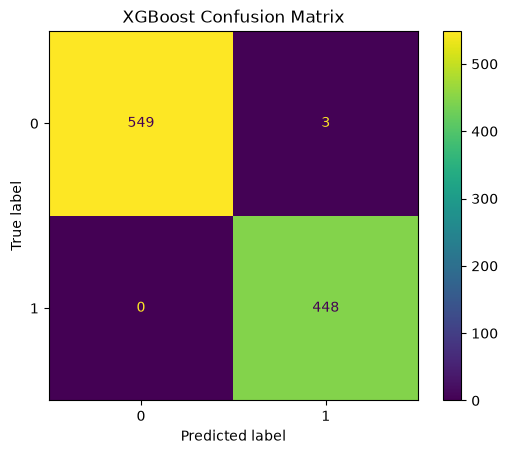

In [42]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

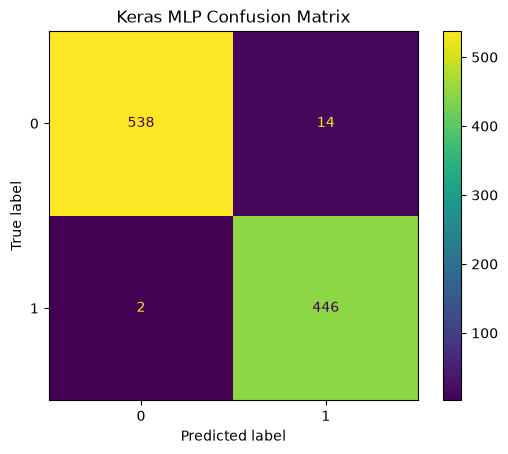

In [43]:
cm_k_mlp = confusion_matrix(y_test, y_pred_k_mlp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_k_mlp)

disp.plot()
plt.title("Keras MLP Confusion Matrix")
plt.show()

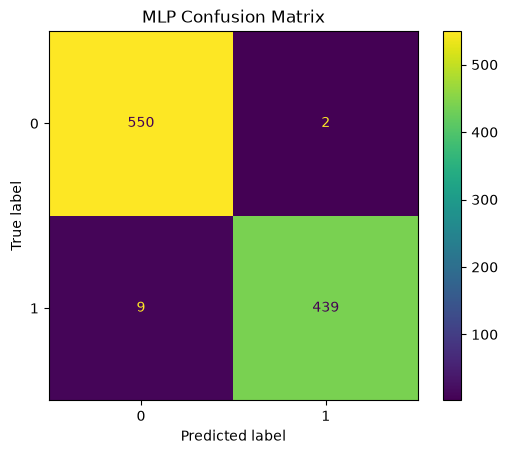

In [44]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp
)

disp.plot()
plt.title("MLP Confusion Matrix")
plt.show()

ROC - AUC

In [ ]:


# --- Get predicted probabilities (positive class) ---
# XGBoost
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Keras MLP
y_proba_k = best_model.predict(X_test).flatten()

# Scikit-learn MLP
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]

# --- Compute ROC curves and AUC ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

fpr_k, tpr_k, _ = roc_curve(y_test, y_proba_k)
auc_k = roc_auc_score(y_test, y_proba_k)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
auc_mlp = roc_auc_score(y_test, y_proba_mlp)

# --- Plot all ROC curves on one figure ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)
plt.plot(fpr_k, tpr_k, label=f'Keras MLP (AUC = {auc_k:.4f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'Sklearn MLP (AUC = {auc_mlp:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Print AUC scores ---
print("\nAUC Scores:")
print(f"XGBoost:        {auc_xgb:.4f}")
print(f"Keras MLP:      {auc_k:.4f}")
print(f"Scikit-learn MLP: {auc_mlp:.4f}")